In [57]:
# Importando o dataset
import pandas as pd

df = pd.read_excel('satveg_planilha.xlsx')
df.head()

,Data,NDVI
0,18/02/2000,0.6671
1,05/03/2000,0.6692
2,21/03/2000,0.7197
3,06/04/2000,0.6641
4,22/04/2000,0.6433


<Axes: >

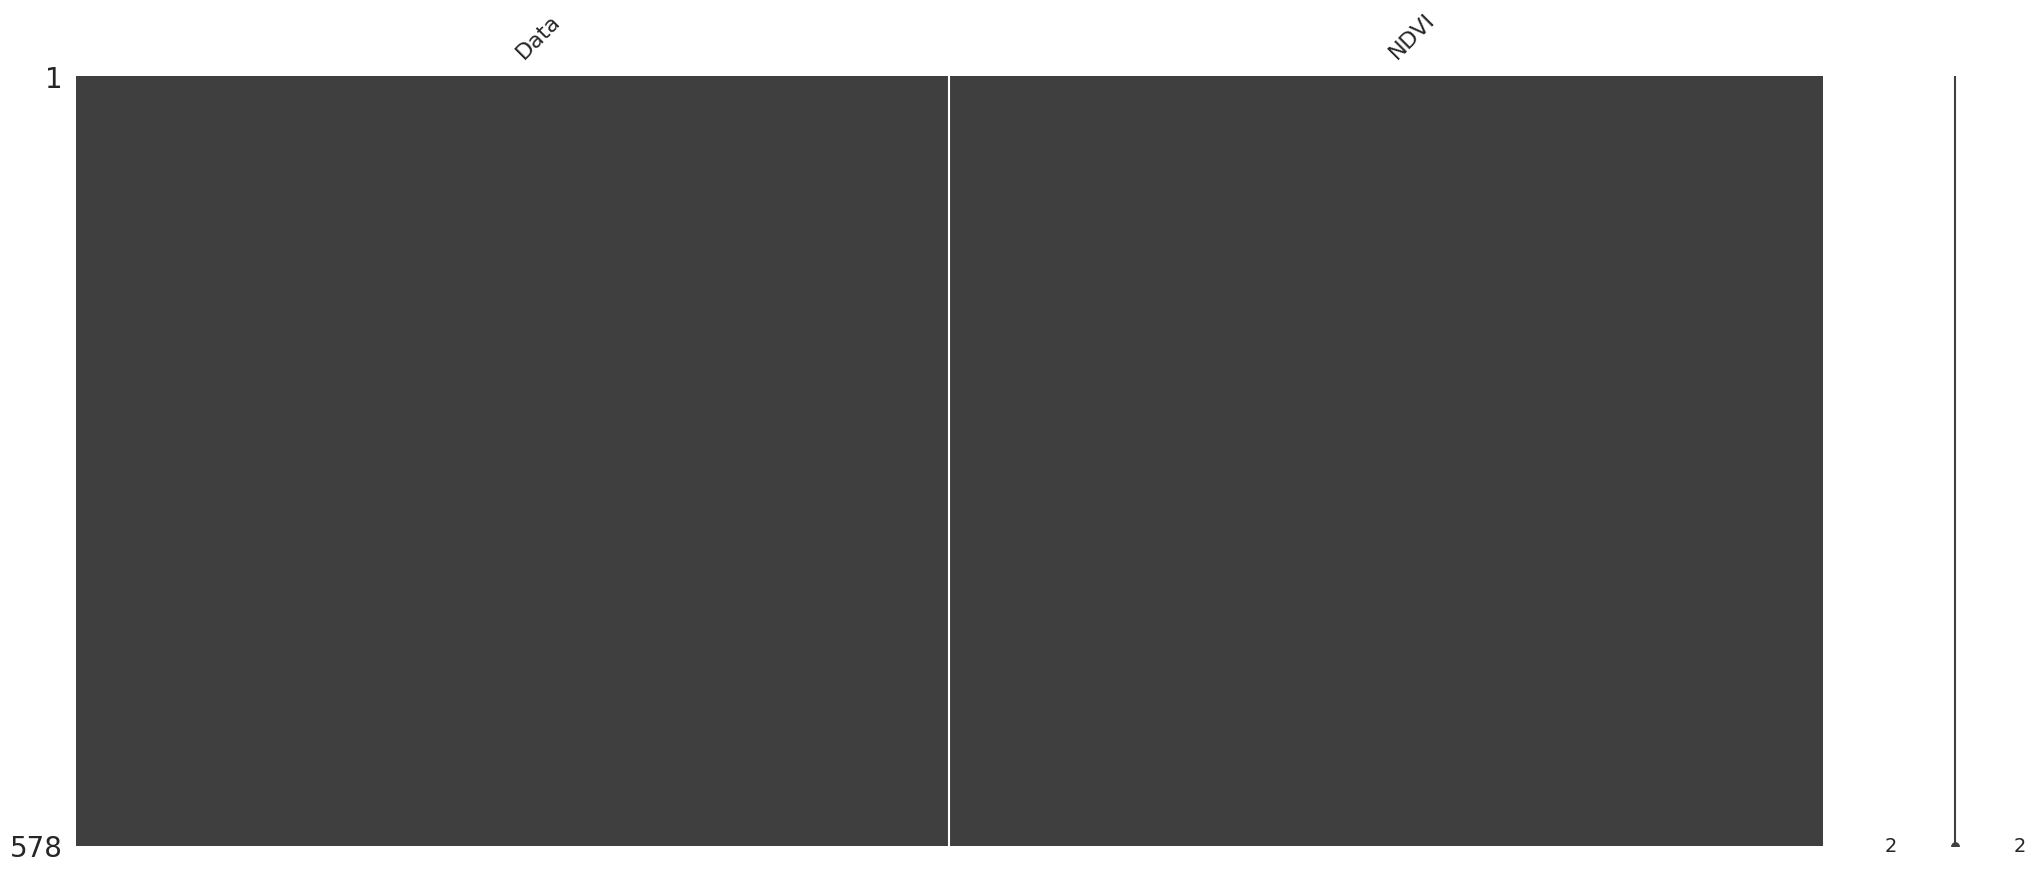

In [58]:
#Vendo se o dataset possui algum valor nulo
import missingno as msno
msno.matrix(df)

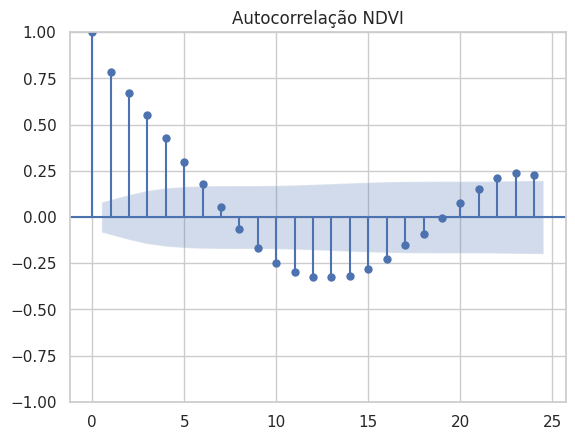

In [59]:
#vendo se o NDVI possui alguma correlação
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df['NDVI'].dropna(), lags=24)
plt.title("Autocorrelação NDVI")
plt.show()


In [60]:
# Agrupar por ano para extração das métricas fenológicas
df['Data'] = pd.to_datetime(df['Data'])
df.set_index('Data', inplace=True)

df['year'] = df.index.year
df['month'] = df.index.month

# Threshold para detectar "estação de crescimento"
threshold = 0.55  # NDVI acima disso é considerado "vegetação ativa"

# Criar dicionário para guardar as métricas
metrics = {
    'Ano': [],
    'NDVI_max': [],
    'Mês_Ultrapassou': [],
    'Mês_Permaneceu': [],
}

# Loop pelos anos
for year, group in df.groupby('year'):
    ndvi_vals = group['NDVI']
    above_thresh = group[ndvi_vals > threshold]

    sos = above_thresh.index.min().month if not above_thresh.empty else None
    eos = above_thresh.index.max().month if not above_thresh.empty else None

    metrics['Ano'].append(year)
    metrics['NDVI_max'].append(ndvi_vals.max())
    metrics['Mês_Ultrapassou'].append(sos) # primeiro mes que o NVDI passou o threshold
    metrics['Mês_Permaneceu'].append(eos) #ultimo mes que o NVDI passou o threshold

metrics_df = pd.DataFrame(metrics)
metrics_df.tail(10)  # Mostrar os últimos 10 anos para revisão recente


<ipython-input-60-955bddad3aa2>:2: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Data'] = pd.to_datetime(df['Data'])


,Ano,NDVI_max,Mês_Ultrapassou,Mês_Permaneceu
16,2016,0.7024,1,10
17,2017,0.8946,1,12
18,2018,0.7332,1,12
19,2019,0.7115,1,12
20,2020,0.7137,1,12
21,2021,0.7642,1,12
22,2022,0.7993,1,12
23,2023,0.8230,1,6
24,2024,0.9211,3,12
25,2025,0.9256,1,3


In [61]:
# Adicionando variáveis-chave ao dataset de métricas derivadas do NDVI

# Calcular a duração da estação de crescimento
metrics_df['Duracao_estacao'] = metrics_df['Mês_Permaneceu'] - metrics_df['Mês_Ultrapassou']

# Calcular NDVI médio e desvio padrão durante a estação de crescimento
ndvi_mean_growing = []
ndvi_std_growing = []
ndvi_integral = []

for _, row in metrics_df.iterrows():
    ano = row['Ano']
    sos = row['Mês_Ultrapassou']
    eos = row['Mês_Permaneceu']

    if pd.notnull(sos) and pd.notnull(eos):
        periodo = df[(df['year'] == ano) &
                          (df['month'] >= sos) &
                          (df['month'] <= eos)]['NDVI']
        ndvi_mean_growing.append(periodo.mean())
        ndvi_std_growing.append(periodo.std())
        ndvi_integral.append(periodo.sum())
    else:
        ndvi_mean_growing.append(None)
        ndvi_std_growing.append(None)
        ndvi_integral.append(None)

metrics_df['NDVI_mean_growing'] = ndvi_mean_growing
metrics_df['NDVI_std_growing'] = ndvi_std_growing
metrics_df['NDVI_integral'] = ndvi_integral

metrics_df.tail(10)  # Mostrar os últimos 10 anos com variáveis derivadas


,Ano,NDVI_max,Mês_Ultrapassou,Mês_Permaneceu,Duracao_estacao,NDVI_mean_growing,NDVI_std_growing,NDVI_integral
16,2016,0.7024,1,10,9,0.552130,0.124126,11.0426
17,2017,0.8946,1,12,11,0.606378,0.125338,13.9467
18,2018,0.7332,1,12,11,0.554783,0.140406,12.7600
19,2019,0.7115,1,12,11,0.557030,0.092166,12.8117
20,2020,0.7137,1,12,11,0.520774,0.125384,11.9778
21,2021,0.7642,1,12,11,0.469209,0.167489,10.7918
22,2022,0.7993,1,12,11,0.574191,0.127113,13.2064
23,2023,0.8230,1,6,5,0.665058,0.084420,7.9807
24,2024,0.9211,3,12,9,0.778689,0.118830,14.7951
25,2025,0.9256,1,3,2,0.915683,0.010513,5.4941


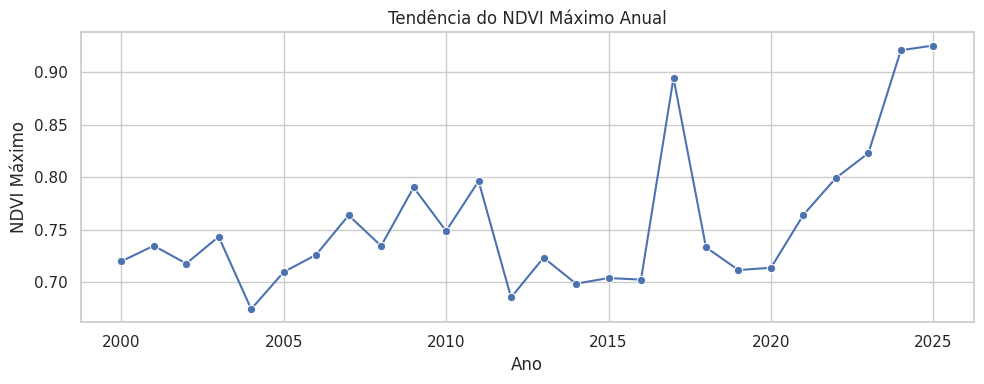

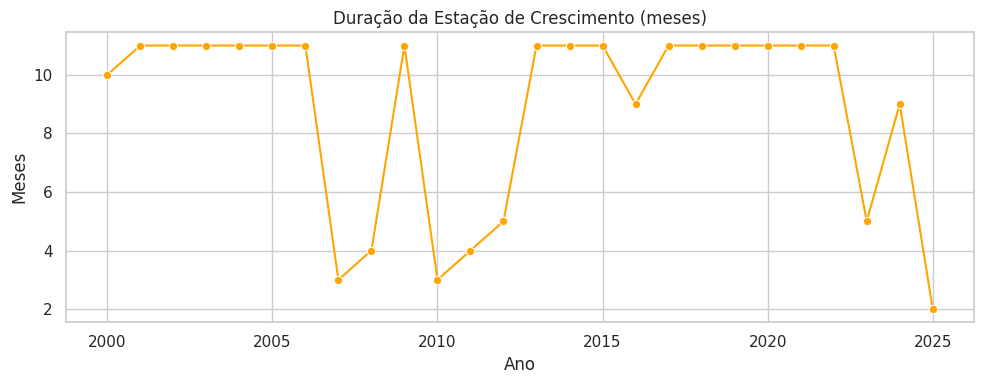

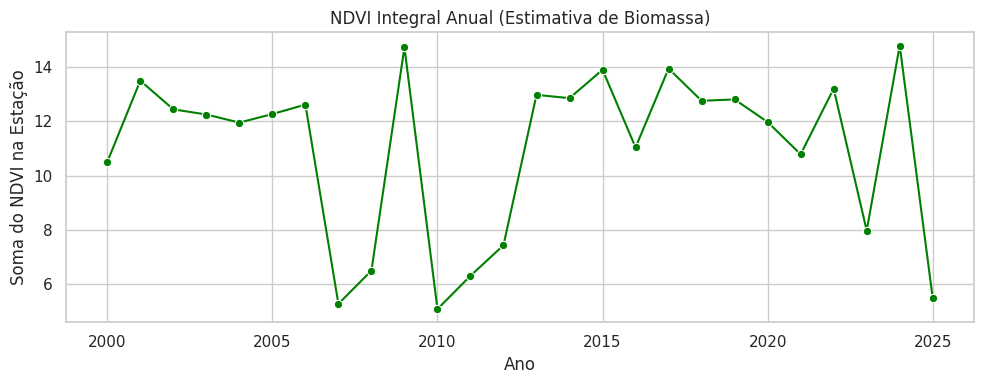

In [62]:
import seaborn as sns

# Definir estilo
sns.set(style="whitegrid")

# Gráfico 1: Tendência do NDVI máximo ao longo dos anos
plt.figure(figsize=(10, 4))
sns.lineplot(data=metrics_df, x='Ano', y='NDVI_max', marker='o')
plt.title('Tendência do NDVI Máximo Anual')
plt.ylabel('NDVI Máximo')
plt.grid(True)
plt.tight_layout()
plt.show()

# Gráfico 2: Duração da estação de crescimento ao longo dos anos
plt.figure(figsize=(10, 4))
sns.lineplot(data=metrics_df, x='Ano', y='Duracao_estacao', marker='o', color='orange')
plt.title('Duração da Estação de Crescimento (meses)')
plt.ylabel('Meses')
plt.grid(True)
plt.tight_layout()
plt.show()

# Gráfico 3: NDVI Integral ao longo dos anos
plt.figure(figsize=(10, 4))
sns.lineplot(data=metrics_df, x='Ano', y='NDVI_integral', marker='o', color='green')
plt.title('NDVI Integral Anual (Estimativa de Biomassa)')
plt.ylabel('Soma do NDVI na Estação')
plt.grid(True)
plt.tight_layout()
plt.show()


In [63]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import pandas as pd
# Aplicando StandardScaler
scaler_standard = StandardScaler()
X_scaled = scaler_standard.fit_transform(X)
# Aplicando MinMaxScaler
scaler_minmax = MinMaxScaler()
X_minmax_scaled = scaler_minmax.fit_transform(X)
# Mostrando as primeiras linhas dos dados escalados
df_scaled = pd.DataFrame(X_scaled, columns=X.columns)
df_scaled.head()
df_minmax = pd.DataFrame(X_minmax_scaled, columns=X.columns)
df_minmax.head()

,NDVI_max,NDVI_mean_growing,NDVI_std_growing,NDVI_integral,Duracao_estacao
0,0.180661,0.125867,0.650903,0.558059,0.888889
1,0.240350,0.263864,0.575839,0.866634,1.000000
2,0.172702,0.161117,0.607507,0.757866,1.000000
3,0.274572,0.142508,0.715783,0.738165,1.000000
4,0.000000,0.113644,0.600224,0.707610,1.000000


In [68]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Lista de modelos de regressão
models = {
    "Random Forest": RandomForestRegressor(),
    "SVR": SVR(),
    "KNN": KNeighborsRegressor(),
    "Regressão Linear": LinearRegression()
}

# Avaliação
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"{name} → RMSE: {rmse:.2f}, R²: {r2:.2f}")

Random Forest → RMSE: 2.21, R²: 0.35
SVR → RMSE: 1.85, R²: 0.55
KNN → RMSE: 1.93, R²: 0.50
Regressão Linear → RMSE: 0.95, R²: 0.88


Como podemos observar acima a regressão Linear teve o melhor desempenho tanto em precisão (menor RMSE) quanto em capacidade explicativa (maior R²), SVR e KNN apresentaram desempenhos medianos, e por ultimo, a random forest foi a que apresentou o pior desempenho